# 🧑‍💻 PR 2. Data Cleaner

# 🏥 Patient Health Records


### Objective

The aim of this project is to identify missing values in a patient
health dataset and apply different missing value imputation techniques.

The following techniques will be tested:

1. Simple Imputer - Numerical
2. Simple Imputer - Categorical
3. Most Frequent Imputation
4. Missing Indicator + Random Sample Imputation
5. KNN Imputer
6. MICE / Iterative Imputation

## 1️⃣ Load Liabaries , Dataset & Generate Information 

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

In [47]:
df=pd.read_csv("patient_health_records.csv")

In [48]:
df.head(10)

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001,53.0,Male,East,25.4,88.0,246.2,71.4,1
1,1002,31.0,Female,North,27.2,125.9,218.9,108.2,0
2,1003,60.0,Female,North,33.1,117.5,194.1,147.5,1
3,1004,63.0,Female,NaN,16.0,132.4,222.3,60.7,0
4,1005,18.0,Male,North,25.4,136.2,193.3,70.0,0
5,1006,27.0,Male,East,27.3,127.2,NaN,91.4,1
6,1007,50.0,Male,North,27.8,137.2,135.4,89.0,0
7,1008,43.0,Female,East,24.8,128.7,192.2,122.3,1
8,1009,48.0,Male,East,10.8,133.5,129.3,108.0,0
9,1010,NaN,Male,East,28.0,113.7,148.2,60.0,1


In [49]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100
Number of columns: 9


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      100 non-null    int64  
 1   age             93 non-null     float64
 2   gender          94 non-null     object 
 3   region          95 non-null     object 
 4   bmi             93 non-null     float64
 5   blood_pressure  100 non-null    float64
 6   cholesterol     94 non-null     float64
 7   glucose         95 non-null     float64
 8   disease_risk    100 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 7.2+ KB


In [51]:
df.describe()

,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,100.000000,93.000000,93.000000,100.000000,94.000000,95.000000,100.000000
mean,1050.500000,47.236559,27.117204,125.595000,203.280851,111.812632,0.560000
std,29.011492,12.506866,5.701766,19.875107,52.579906,68.512967,0.498888
min,1001.000000,18.000000,10.800000,72.000000,55.000000,60.000000,0.000000
25%,1025.750000,40.000000,23.900000,115.450000,173.975000,86.400000,0.000000
50%,1050.500000,48.000000,27.400000,126.000000,201.700000,100.000000,1.000000
75%,1075.250000,56.000000,30.200000,134.450000,225.025000,117.500000,1.000000
max,1100.000000,82.000000,58.500000,238.000000,515.000000,520.000000,1.000000


## Missing Value

In [52]:
missing_values = df.isnull().sum()
print("missing_values:")
print(missing_values)

missing_values:
patient_id        0
age               7
gender            6
region            5
bmi               7
blood_pressure    0
cholesterol       6
glucose           5
disease_risk      0
dtype: int64


In [53]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_data_Report = pd.DataFrame ({"Missing Values":missing_count,
                                     "Misiing Persentage":missing_percentage.round(2)})
missing_data_Report

,Missing Values,Misiing Persentage
patient_id,0,0.0
age,7,7.0
gender,6,6.0
region,5,5.0
bmi,7,7.0
blood_pressure,0,0.0
cholesterol,6,6.0
glucose,5,5.0
disease_risk,0,0.0


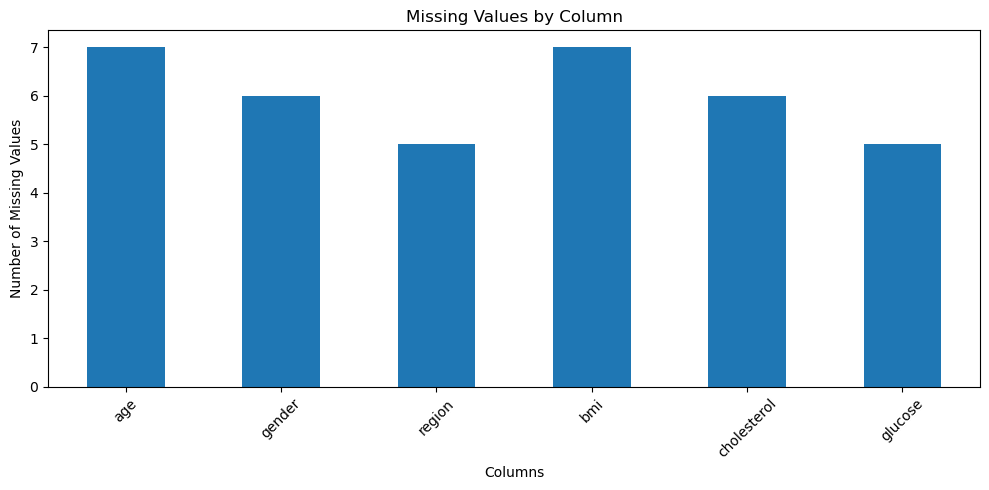

In [54]:
# ============================================
# GRAPH 1: MISSING VALUES
# ============================================

# Count missing values
missing_values = df.isnull().sum()

# Keep only columns having missing values
missing_values = missing_values[missing_values > 0]

# Create bar chart
plt.figure(figsize=(10, 5))

missing_values.plot(kind='bar')

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# IMPUTATION

## 1️⃣ Simple Imputer — Numerical BMI

In [55]:
print("BMI Mean:",df["bmi"].mean())
print("BMI Median:",df["bmi"].median())

BMI Mean: 27.117204301075265
BMI Median: 27.4


In [56]:
df_simple = df.copy()
bmi_imputer = SimpleImputer(strategy="median")
df_simple["bmi"] = bmi_imputer.fit_transform(df_simple[["bmi"]]).ravel()

In [57]:
print("Missing BMI after imputation:")
print(df_simple["bmi"].isnull().sum())

Missing BMI after imputation:
0


## 2️⃣ Simple Imputer — Region

In [58]:
df["region"].value_counts()

region
North    33
West     24
East     22
South    16
Name: count, dtype: int64

In [59]:
region_imputer = SimpleImputer(
    strategy="most_frequent")

df_simple["region"] = region_imputer.fit_transform(
    df_simple[["region"]]
).ravel()

In [60]:
print ("Missing Region")
print(df_simple["region"].isnull().sum())

Missing Region
0


## 3️⃣ Most Frequent Imputation — Gender

In [61]:
df["gender"].value_counts()

gender
Male      51
Female    43
Name: count, dtype: int64

In [62]:
gender_imputer = SimpleImputer(
    strategy="most_frequent")
df_simple["gender"] = gender_imputer.fit_transform(
    df_simple[["gender"]]).ravel()

In [63]:
print ("Missing Gender")
print(df_simple["gender"].isnull().sum())

Missing Gender
0


# 4️⃣ Missing Indicator 

In [64]:
df_indicator = df.copy()

df_indicator["age_missing"] = (
    df_indicator["age"].isnull().astype(int)
)

df_indicator["bmi_missing"] = (
    df_indicator["bmi"].isnull().astype(int)
)

df_indicator["cholesterol_missing"] = (
    df_indicator["cholesterol"].isnull().astype(int)
)

df_indicator["glucose_missing"] = (
    df_indicator["glucose"].isnull().astype(int)
)

df_indicator.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing,bmi_missing,cholesterol_missing,glucose_missing
0,1001,53.0,Male,East,25.4,88.0,246.2,71.4,1,0,0,0,0
1,1002,31.0,Female,North,27.2,125.9,218.9,108.2,0,0,0,0,0
2,1003,60.0,Female,North,33.1,117.5,194.1,147.5,1,0,0,0,0
3,1004,63.0,Female,NaN,16.0,132.4,222.3,60.7,0,0,0,0,0
4,1005,18.0,Male,North,25.4,136.2,193.3,70.0,0,0,0,0,0


# 5️⃣ Random Sample Imputation 

In [65]:
numerical_columns = [
    "age",
    "bmi",
    "blood_pressure",
    "cholesterol",
    "glucose"
]

numerical_columns

['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']

In [66]:
categorical_columns = [
    "gender",
    "region"
]

categorical_columns

['gender', 'region']

In [67]:
df_random = df.copy()

np.random.seed(42)

for column in numerical_columns:

    missing = df_random[column].isnull()

    available_values = df_random.loc[
        df_random[column].notnull(),
        column
    ]

    random_values = np.random.choice(
        available_values,
        size=missing.sum(),
        replace=True
    )

    df_random.loc[
        missing,
        column
    ] = random_values

In [68]:
for column in categorical_columns:

    missing = df_random[column].isnull()

    available_values = df_random.loc[
        df_random[column].notnull(),
        column
    ]

    random_values = np.random.choice(
        available_values,
        size=missing.sum(),
        replace=True
    )

    df_random.loc[
        missing,
        column
    ] = random_values

In [69]:
df_random.isnull().sum()

patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

# 6️⃣ KNN Imputer

In [70]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numeric_cols))

Numerical Columns:
['patient_id', 'age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'disease_risk']


In [159]:
knn_imputer = KNNImputer(n_neighbors=5)

df_knn = df.copy()

df_knn[numeric_cols] = knn_imputer.fit_transform(
    df_knn[numeric_cols]
)

In [160]:
print("Missing values after KNN Imputation:")

df_knn[numeric_cols].isnull().sum()

Missing values after KNN Imputation:


patient_id        0
age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

# 7️⃣ Mice Imputer

In [161]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [162]:
mice_imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

In [163]:
df_mice = df.copy()

df_mice[numeric_cols] = mice_imputer.fit_transform(
    df_mice[numeric_cols]
)

In [164]:
print("Missing values after MICE Imputation:")

df_mice[numeric_cols].isnull().sum()

Missing values after MICE Imputation:


patient_id        0
age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

In [165]:
# Compare original and MICE-imputed values

mice_comparison = pd.DataFrame({
    "Original Age": df["age"],
    "MICE Age": df_mice["age"],
    "Original BMI": df["bmi"],
    "MICE BMI": df_mice["bmi"],
    "Original Cholesterol": df["cholesterol"],
    "MICE Cholesterol": df_mice["cholesterol"],
    "Original Glucose": df["glucose"],
    "MICE Glucose": df_mice["glucose"]
})

mice_comparison.head(10)

,Original Age,MICE Age,Original BMI,MICE BMI,Original Cholesterol,MICE Cholesterol,Original Glucose,MICE Glucose
0,53.0,53.000000,25.4,25.4,246.2,246.20000,71.4,71.4
1,31.0,31.000000,27.2,27.2,218.9,218.90000,108.2,108.2
2,60.0,60.000000,33.1,33.1,194.1,194.10000,147.5,147.5
3,63.0,63.000000,16.0,16.0,222.3,222.30000,60.7,60.7
4,18.0,18.000000,25.4,25.4,193.3,193.30000,70.0,70.0
5,27.0,27.000000,27.3,27.3,NaN,203.21876,91.4,91.4
6,50.0,50.000000,27.8,27.8,135.4,135.40000,89.0,89.0
7,43.0,43.000000,24.8,24.8,192.2,192.20000,122.3,122.3
8,48.0,48.000000,10.8,10.8,129.3,129.30000,108.0,108.0
9,NaN,48.009042,28.0,28.0,148.2,148.20000,60.0,60.0


# Part B — Handling Outliers

In [166]:
from scipy import stats

In [167]:
df.describe()

,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,100.000000,93.000000,93.000000,100.000000,94.000000,95.000000,100.000000
mean,1050.500000,47.236559,27.117204,125.595000,203.280851,111.812632,0.560000
std,29.011492,12.506866,5.701766,19.875107,52.579906,68.512967,0.498888
min,1001.000000,18.000000,10.800000,72.000000,55.000000,60.000000,0.000000
25%,1025.750000,40.000000,23.900000,115.450000,173.975000,86.400000,0.000000
50%,1050.500000,48.000000,27.400000,126.000000,201.700000,100.000000,1.000000
75%,1075.250000,56.000000,30.200000,134.450000,225.025000,117.500000,1.000000
max,1100.000000,82.000000,58.500000,238.000000,515.000000,520.000000,1.000000


# 1️⃣ Z-Score

## B1. Z-Score Method

The Z-score method is used to identify extreme values in the Cholesterol and Glucose columns.

A value with an absolute Z-score greater than 3 is treated as a potential extreme outlier.

In [168]:
# Import z-Score
from scipy.stats import zscore

In [169]:
# Create a safe copy of the original dataset
df_before = df.copy()

print("Before Outlier Treatment:", df_before.shape)

Before Outlier Treatment: (100, 9)


### Cholesterol Outliers

In [170]:
df_zscore = df_before.copy()

df_zscore["cholesterol_zscore"] = zscore(
    df_zscore["cholesterol"].fillna(
        df_zscore["cholesterol"].median()
    )
)

df_zscore[["cholesterol", "cholesterol_zscore"]].head()

,cholesterol,cholesterol_zscore
0,246.2,0.848275
1,218.9,0.309894
2,194.1,-0.179184
3,222.3,0.376945
4,193.3,-0.194961


In [171]:
cholesterol_outliers = df_zscore[
    df_zscore["cholesterol_zscore"].abs() > 3
]

print("Number of Cholesterol Outliers:",
      len(cholesterol_outliers))

cholesterol_outliers[
    ["cholesterol", "cholesterol_zscore"]
]

Number of Cholesterol Outliers: 1


,cholesterol,cholesterol_zscore
91,515.0,6.149254


### Glucose outlier

In [172]:
df_zscore["glucose_zscore"] = zscore(
    df_zscore["glucose"].fillna(
        df_zscore["glucose"].median()
    )
)

df_zscore[["glucose", "glucose_zscore"]].head()

,glucose,glucose_zscore
0,71.4,-0.599046
1,108.2,-0.045460
2,147.5,0.545734
3,60.7,-0.760008
4,70.0,-0.620107


In [173]:
glucose_outliers = df_zscore[
    df_zscore["glucose_zscore"].abs() > 3
]

print("Number of Glucose Outliers:",
      len(glucose_outliers))

glucose_outliers[
    ["glucose", "glucose_zscore"]
]

Number of Glucose Outliers: 3


,glucose,glucose_zscore
14,395.0,4.268901
48,465.0,5.321918
83,520.0,6.149289


### Remove Z-Score Outliers

In [174]:
df_zscore_final = df_zscore[
    (df_zscore["cholesterol_zscore"].abs() <= 3) &
    (df_zscore["glucose_zscore"].abs() <= 3)
].copy()

print("Before Z-Score Treatment:", df_before.shape)
print("After Z-Score Treatment:", df_zscore_final.shape)

Before Z-Score Treatment: (100, 9)
After Z-Score Treatment: (96, 11)


### Temporary Remove  Z-Score Columns

In [175]:
df_zscore_final.drop(
    columns=[
        "cholesterol_zscore",
        "glucose_zscore"
    ],
    inplace=True
)

df_zscore_final.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001,53.0,Male,East,25.4,88.0,246.2,71.4,1
1,1002,31.0,Female,North,27.2,125.9,218.9,108.2,0
2,1003,60.0,Female,North,33.1,117.5,194.1,147.5,1
3,1004,63.0,Female,NaN,16.0,132.4,222.3,60.7,0
4,1005,18.0,Male,North,25.4,136.2,193.3,70.0,0


### Combined Before vs After Graph
### Cholesterol and Glucose

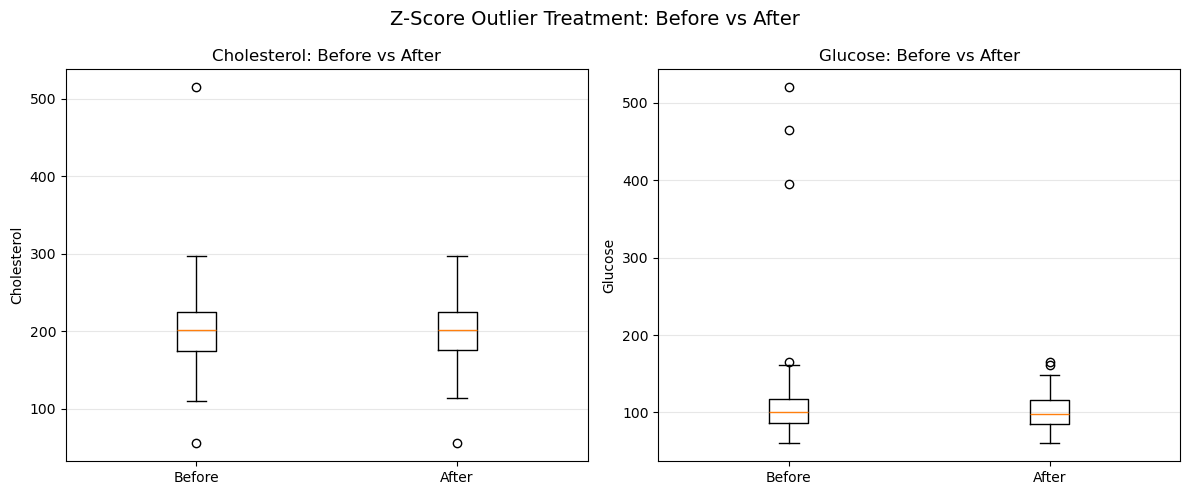

In [176]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cholesterol
axes[0].boxplot([
    df_before["cholesterol"].dropna(),
    df_zscore_final["cholesterol"].dropna()
])

axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Before", "After"])
axes[0].set_title("Cholesterol: Before vs After")
axes[0].set_ylabel("Cholesterol")
axes[0].grid(axis="y", alpha=0.3)

# Glucose
axes[1].boxplot([
    df_before["glucose"].dropna(),
    df_zscore_final["glucose"].dropna()
])

axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Before", "After"])
axes[1].set_title("Glucose: Before vs After")
axes[1].set_ylabel("Glucose")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Z-Score Outlier Treatment: Before vs After", fontsize=14)

plt.tight_layout()
plt.show()

### Interpretation

The Z-score method identified extreme Cholesterol and Glucose values. After treatment, the extreme observations were removed, reducing the influence of unusually high or low values.

# 2️⃣IQR Method

The IQR method is used to identify unusual BMI values using the first quartile (Q1), third quartile (Q3), and the interquartile range (IQR).

In [177]:
# Create a copy after Z-score treatment

df_iqr = df_zscore_final.copy()

print("Dataset shape before BMI treatment:", df_iqr.shape)

Dataset shape before BMI treatment: (96, 9)


In [178]:
print(df_iqr["bmi"].describe())

count    89.000000
mean     26.980899
std       5.769628
min      10.800000
25%      23.800000
50%      27.300000
75%      30.000000
max      58.500000
Name: bmi, dtype: float64


### Calculate Q1, Q3 and IQR

In [179]:
Q1 = df_iqr["bmi"].quantile(0.25)
Q3 = df_iqr["bmi"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 23.8
Q3: 30.0
IQR: 6.199999999999999
Lower Bound: 14.500000000000002
Upper Bound: 39.3


### Graph : bmi - Before IQR Outlier Treatment

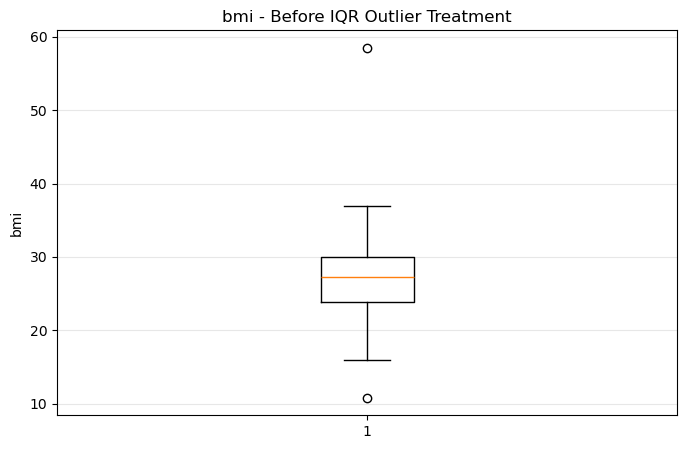

In [180]:
plt.figure(figsize=(8, 5))

plt.boxplot(df_iqr["bmi"].dropna())

plt.title("bmi - Before IQR Outlier Treatment")
plt.ylabel("bmi")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Identify Bmi Outlier

In [181]:
bmi_outliers = df_iqr[
    (df_iqr["bmi"] < lower_bound) |
    (df_iqr["bmi"] > upper_bound)
]

print("Number of bmi Outliers:", len(bmi_outliers))

bmi_outliers[["bmi"]]

Number of bmi Outliers: 2


,bmi
8,10.8
67,58.5


### Remove BMI Outlier

In [182]:
df_iqr_final = df_iqr[
    (df_iqr["bmi"] >= lower_bound) &
    (df_iqr["bmi"] <= upper_bound)
].copy()

print("Before bmi Treatment:", df_iqr.shape)
print("After bmi Treatment:", df_iqr_final.shape)

Before bmi Treatment: (96, 9)
After bmi Treatment: (87, 9)


###  GRAPH : BMI BEFORE VS AFTER

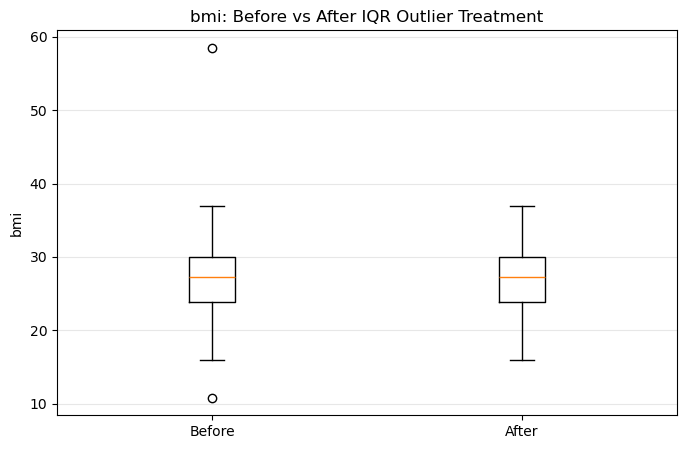

In [183]:
plt.figure(figsize=(8, 5))

plt.boxplot([
    df_iqr["bmi"].dropna(),
    df_iqr_final["bmi"].dropna()
])

plt.xticks(
    [1, 2],
    ["Before", "After"]
)

plt.title("bmi: Before vs After IQR Outlier Treatment")
plt.ylabel("bmi")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [184]:
print("========== IQR SUMMARY ==========")

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nBMI Outliers:", len(bmi_outliers))

print("Rows Before:", df_iqr.shape[0])
print("Rows After:", df_iqr_final.shape[0])

print("Rows Removed:",
      df_iqr.shape[0] - df_iqr_final.shape[0])

========== IQR SUMMARY ==========
Q1: 23.8
Q3: 30.0
IQR: 6.199999999999999
Lower Bound: 14.500000000000002
Upper Bound: 39.3

BMI Outliers: 2
Rows Before: 96
Rows After: 87
Rows Removed: 9


### Interpretation

The IQR method identified BMI values outside the normal IQR range. After treatment, these extreme BMI observations were removed and the distribution became less affected by extreme values.

# 3️⃣ Percentile Method — 1st and 99th Percentile 
The percentile method identifies extreme values using the 1st and 99th percentiles. The remaining numerical variables are checked using these percentile limits.

In [185]:
# Continue from the IQR-treated dataset

df_percentile = df_iqr_final.copy()

print("Dataset shape before percentile treatment:", df_percentile.shape)

Dataset shape before percentile treatment: (87, 9)


### fIND OTHER NUMERICAL COLUMN

In [186]:
# Columns that should NOT be included in percentile outlier treatment

excluded_columns = [
    "patient_id",
    "age",
    "cholesterol",
    "glucose",
    "BMI"
]

# Find remaining numerical columns

percentile_columns = [
    column
    for column in df_iqr_final.select_dtypes(include="number").columns
    if column not in excluded_columns
]

print("Columns for Percentile Method:")
print(percentile_columns)

Columns for Percentile Method:
['bmi', 'blood_pressure', 'disease_risk']


### Calculate 1st and 99th Percentile

In [187]:
percentile_limits = {}

for column in percentile_columns:
    
    lower_limit = df_iqr_final[column].quantile(0.01)
    upper_limit = df_iqr_final[column].quantile(0.99)
    
    percentile_limits[column] = {
        "1st Percentile": lower_limit,
        "99th Percentile": upper_limit
    }

percentile_limits_df = pd.DataFrame(percentile_limits).T

percentile_limits_df

,1st Percentile,99th Percentile
bmi,16.172,35.022
blood_pressure,85.502,159.376
disease_risk,0.000,1.000


### Count Persentile Outlear

In [188]:
percentile_outlier_counts = {}

for column in percentile_columns:
    
    lower_limit = percentile_limits[column]["1st Percentile"]
    upper_limit = percentile_limits[column]["99th Percentile"]
    
    outlier_count = (
        (df_iqr_final[column] < lower_limit) |
        (df_iqr_final[column] > upper_limit)
    ).sum()
    
    percentile_outlier_counts[column] = outlier_count

print("Percentile Outlier Counts:")

for column, count in percentile_outlier_counts.items():
    print(column, ":", count)

Percentile Outlier Counts:
bmi : 2
blood_pressure : 2
disease_risk : 0


### 


Remove Outlier

In [189]:
df_percentile_removed = df_iqr_final.copy()

for column in percentile_columns:
    
    lower_limit = percentile_limits[column]["1st Percentile"]
    upper_limit = percentile_limits[column]["99th Percentile"]
    
    df_percentile_removed = df_percentile_removed[
        (df_percentile_removed[column] >= lower_limit) &
        (df_percentile_removed[column] <= upper_limit)
    ].copy()

### Before And After Graph

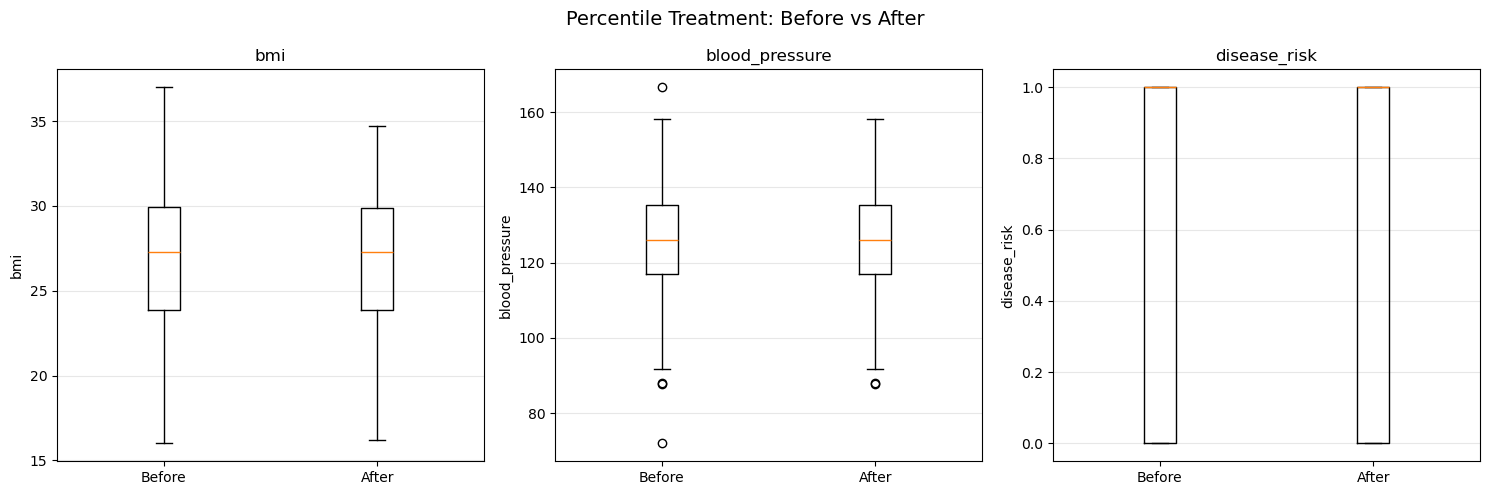

In [190]:
fig, axes = plt.subplots(
    1,
    len(percentile_columns),
    figsize=(5 * len(percentile_columns), 5)
)

# If there is only one column
if len(percentile_columns) == 1:
    axes = [axes]

for ax, column in zip(axes, percentile_columns):
    
    ax.boxplot([
        df_iqr_final[column].dropna(),
        df_percentile_removed[column].dropna()
    ])
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Before", "After"])
    
    ax.set_title(column)
    ax.set_ylabel(column)
    
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Percentile Treatment: Before vs After",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Interpretation

The 1st and 99th percentile method identified extreme values in the selected health-related numerical columns. The extreme observations were removed, while Patient ID and Age were excluded from outlier treatment.

# 1️⃣ Winsorization 

In this step, I will use Winsorization as an alternative to removing outliers.

Extreme values will be capped at the 1st and 99th percentile limits instead of deleting the patient records.

Patient ID and Age are excluded from this treatment.

In [191]:
from scipy.stats.mstats import winsorize

In [206]:
# Select numerical columns 
numeric_columns = df_before.select_dtypes(
    include="number"
).columns.tolist()

# Remove Patient ID from numerical analysis
if "patient_id" in numeric_columns:
    numeric_columns.remove("patient_id")

# Remove missing-indicator columns
numeric_columns = [
    col for col in numeric_columns
    if not col.endswith("_missing")
]

print("Numerical columns used for comparison:")
print(numeric_columns)

Numerical columns used for comparison:
['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'disease_risk']


In [207]:
df_winsorized = df_before.copy()

print("Original Dataset Shape:", df_before.shape)
print("Winsorized Dataset Shape:", df_winsorized.shape)

Original Dataset Shape: (100, 9)
Winsorized Dataset Shape: (100, 9)


In [208]:
winsor_columns = percentile_columns.copy()

print("Columns for Winsorization:")
print(winsor_columns)

Columns for Winsorization:
['bmi', 'blood_pressure', 'disease_risk']


In [209]:
winsor_limits = {}

for column in winsor_columns:
    
    lower_limit = df_winsorized[column].quantile(0.01)
    upper_limit = df_winsorized[column].quantile(0.99)
    
    winsor_limits[column] = {
        "1st Percentile": lower_limit,
        "99th Percentile": upper_limit
    }

winsor_limits_df = pd.DataFrame(winsor_limits).T

winsor_limits_df

,1st Percentile,99th Percentile
bmi,15.584,38.720
blood_pressure,87.543,167.314
disease_risk,0.000,1.000


### Apply Winsorization

In [210]:
for column in winsor_columns:
    
    lower_limit = winsor_limits[column]["1st Percentile"]
    upper_limit = winsor_limits[column]["99th Percentile"]
    
    df_winsorized[column] = df_winsorized[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Winsorization completed successfully.")

Winsorization completed successfully.


### Compare BMI before and after Winsorization

In [211]:


print("Before Winsorization:")
print(df["bmi"].describe())

print("\nAfter Winsorization:")
print(df_winsorized["bmi"].describe())

Before Winsorization:
count    93.000000
mean     27.117204
std       5.701766
min      10.800000
25%      23.900000
50%      27.400000
75%      30.200000
max      58.500000
Name: bmi, dtype: float64

After Winsorization:
count    93.000000
mean     26.955957
std       4.668375
min      15.584000
25%      23.900000
50%      27.400000
75%      30.200000
max      38.720000
Name: bmi, dtype: float64


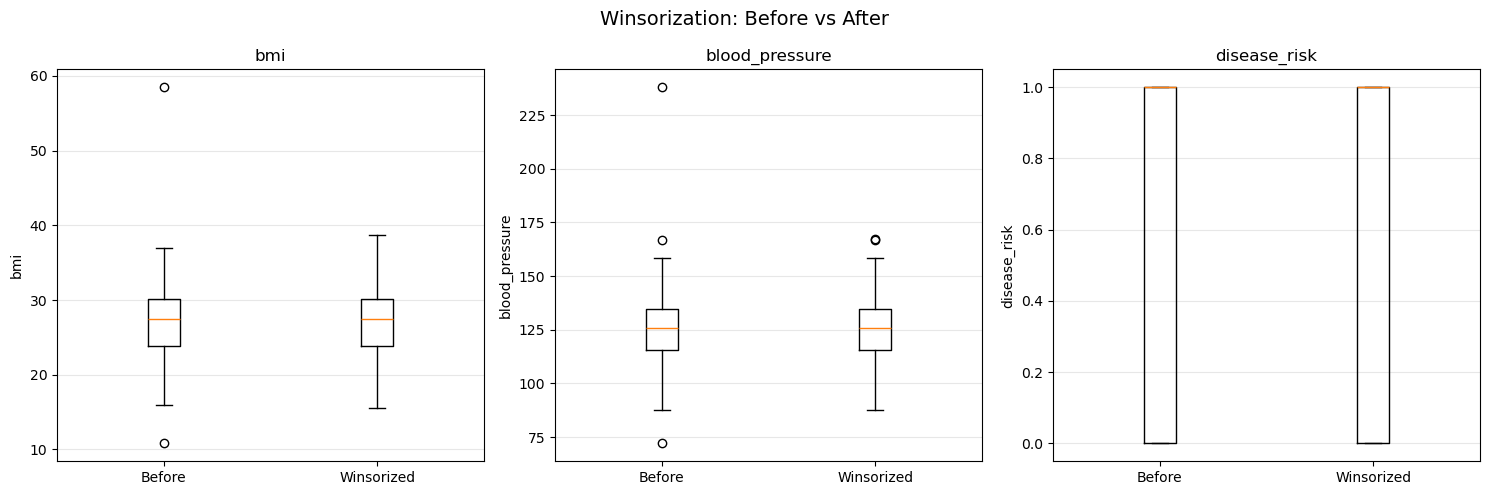

In [212]:
fig, axes = plt.subplots(
    1,
    len(winsor_columns),
    figsize=(5 * len(winsor_columns), 5)
)

if len(winsor_columns) == 1:
    axes = [axes]

for ax, column in zip(axes, winsor_columns):
    
    ax.boxplot([
        df_before[column].dropna(),
        df_winsorized[column].dropna()
    ])
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Before", "Winsorized"])
    
    ax.set_title(column)
    ax.set_ylabel(column)
    
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Winsorization: Before vs After",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [213]:
print("========== WINSORIZATION CHECK ==========")

print("Before Shape:",
      df_before.shape)

print("Winsorized Shape:",
      df_winsorized.shape)

print(
    "Rows Difference:",
    df_before.shape[0] -
    df_winsorized.shape[0]
)

========== WINSORIZATION CHECK ==========
Before Shape: (100, 9)
Winsorized Shape: (100, 9)
Rows Difference: 0


### Compare Maxsimum Values

In [214]:
max_comparison = pd.DataFrame({
    "Before": df_before[winsor_columns].max(),
    "Winsorized": df_winsorized[winsor_columns].max()
})

max_comparison


,Before,Winsorized
bmi,58.5,38.720
blood_pressure,238.0,167.314
disease_risk,1.0,1.000


### Compare Minimum Values

In [215]:
min_comparison = pd.DataFrame({
    "Before": df_before[winsor_columns].min(),
    "Winsorized": df_winsorized[winsor_columns].min()
})

min_comparison

,Before,Winsorized
bmi,10.8,15.584
blood_pressure,72.0,87.543
disease_risk,0.0,0.000


### Graph Before and After

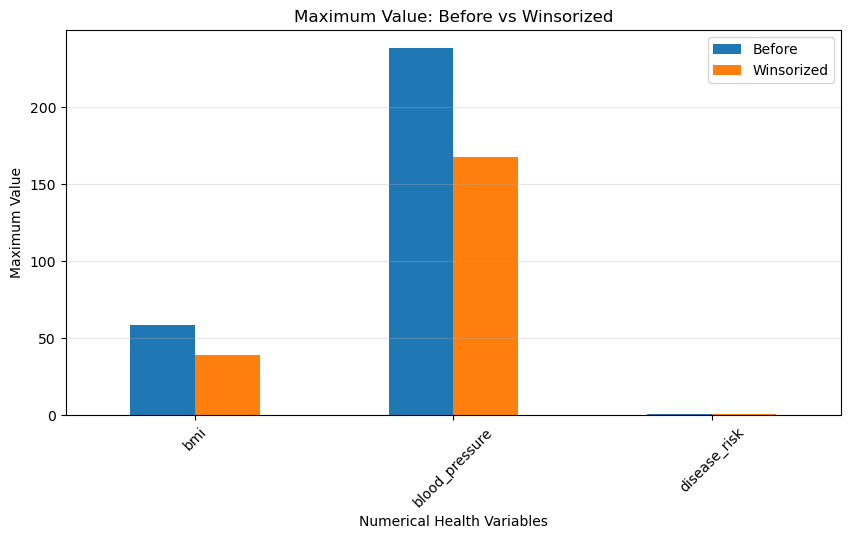

In [216]:
max_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Maximum Value: Before vs Winsorized")
plt.xlabel("Numerical Health Variables")
plt.ylabel("Maximum Value")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation

Winsorization capped extreme values at the 1st and 99th percentile limits without removing patient records. The dataset size therefore remained unchanged.

# 3️⃣ Campare Before & After


In this final step, I compare the original dataset with the outlier-removed and Winsorized datasets.

The comparison focuses on dataset size, summary statistics, extreme values, and the effect of outlier treatment.

In [217]:
print("========== FINAL DATASET CHECK ==========")

print("Original Dataset:", df_before.shape)

print(
    "Outliers Removed:",
    df_percentile_removed.shape
)

print(
    "Winsorized:",
    df_winsorized.shape
)

========== FINAL DATASET CHECK ==========
Original Dataset: (100, 9)
Outliers Removed: (83, 9)
Winsorized: (100, 9)


### Mean Comparison: Before vs Outliers Removed vs Winsorized

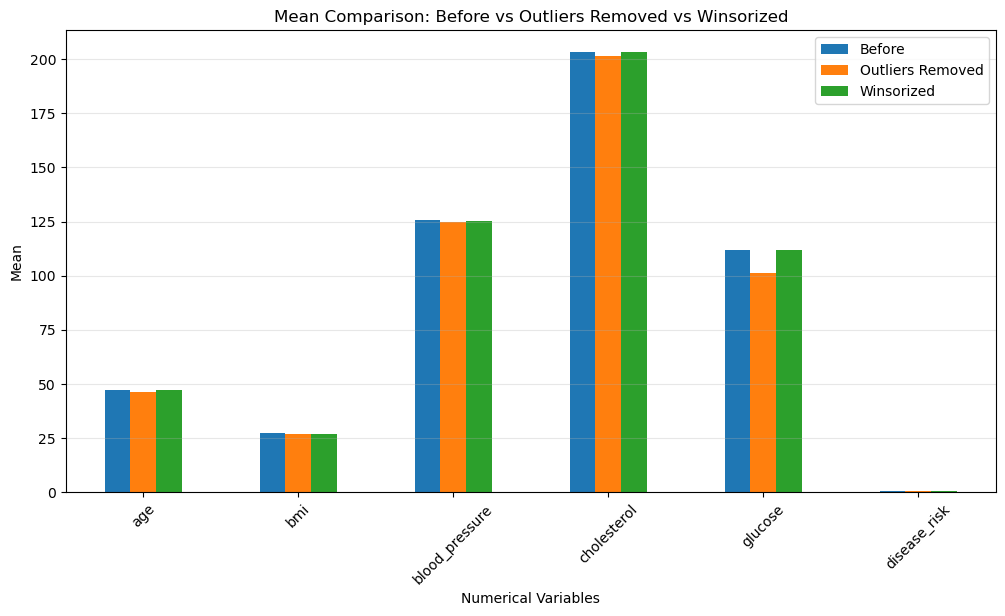

In [218]:
mean_comparison = pd.DataFrame({
    "Before": df_before[numeric_columns].mean(),
    "Outliers Removed": df_percentile_removed[numeric_columns].mean(),
    "Winsorized": df_winsorized[numeric_columns].mean()
})

mean_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Mean Comparison: Before vs Outliers Removed vs Winsorized"
)

plt.xlabel("Numerical Variables")
plt.ylabel("Mean")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Min Max comparison(Winsorized)

In [219]:
min_max_comparison = pd.DataFrame({
    "Before Min": df_before[numeric_columns].min(),
    "After Removal Min": df_percentile_removed[numeric_columns].min(),
    "Winsorized Min": df_winsorized[numeric_columns].min(),
    
    "Before Max": df_before[numeric_columns].max(),
    "After Removal Max": df_percentile_removed[numeric_columns].max(),
    "Winsorized Max": df_winsorized[numeric_columns].max()
})

min_max_comparison

,Before Min,After Removal Min,Winsorized Min,Before Max,After Removal Max,Winsorized Max
age,18.0,18.0,18.000,82.0,82.0,82.000
bmi,10.8,16.2,15.584,58.5,34.7,38.720
blood_pressure,72.0,87.7,87.543,238.0,158.2,167.314
cholesterol,55.0,55.0,55.000,515.0,297.0,515.000
glucose,60.0,60.0,60.000,520.0,165.7,520.000
disease_risk,0.0,0.0,0.000,1.0,1.0,1.000


### Std comparison (Before and After)

In [220]:
std_comparison = pd.DataFrame({
    "Before": df_before[numeric_columns].std(),
    "Outliers Removed": df_percentile_removed[numeric_columns].std(),
    "Winsorized": df_winsorized[numeric_columns].std()
})

std_comparison

,Before,Outliers Removed,Winsorized
age,12.506866,12.821938,12.506866
bmi,5.701766,4.179990,4.668375
blood_pressure,19.875107,15.524786,16.440183
cholesterol,52.579906,40.483453,52.579906
glucose,68.512967,25.728795,68.512967
disease_risk,0.498888,0.500073,0.498888


###  Z-score Before vs After comparison

In [221]:
zscore_comparison = pd.DataFrame({
    "Cholesterol Before": df_before["cholesterol"].describe(),
    "Cholesterol After": df_zscore_final["cholesterol"].describe(),
    "Glucose Before": df_before["glucose"].describe(),
    "Glucose After": df_zscore_final["glucose"].describe()
})

zscore_comparison

,Cholesterol Before,Cholesterol After,Glucose Before,Glucose After
count,94.000000,90.000000,95.000000,91.000000
mean,203.280851,202.206667,111.812632,100.270330
std,52.579906,39.959538,68.512967,25.282455
min,55.000000,55.000000,60.000000,60.000000
25%,173.975000,176.025000,86.400000,85.250000
50%,201.700000,202.000000,100.000000,97.800000
75%,225.025000,225.025000,117.500000,115.500000
max,515.000000,297.000000,520.000000,165.700000


### Interpretation
The Z-score treatment reduced the effect of extreme Cholesterol and Glucose values by removing observations with extreme Z-scores.

### BMI Before vs After IQR treatment

In [222]:

iqr_comparison = pd.DataFrame({
    "BMI Before": df_iqr["bmi"].describe(),
    "BMI After": df_iqr_final["bmi"].describe()
})

iqr_comparison

,BMI Before,BMI After
count,89.000000,87.000000
mean,26.980899,26.804598
std,5.769628,4.408525
min,10.800000,16.000000
25%,23.800000,23.850000
50%,27.300000,27.300000
75%,30.000000,29.950000
max,58.500000,37.000000


### Interpretation

The IQR method removed BMI values outside the calculated lower and upper limits, reducing the influence of extreme BMI observations.

### Percentile Before vs After comparison

In [223]:


percentile_comparison = pd.DataFrame({
    "Before": df_iqr_final[percentile_columns].mean(),
    "After": df_percentile_removed[percentile_columns].mean()
})

percentile_comparison

,Before,After
bmi,26.804598,26.798795
blood_pressure,124.783908,124.886747
disease_risk,0.563218,0.554217


### Interpretation

The percentile method reduced the effect of extreme values in the selected numerical health variables by removing observations outside the 1st and 99th percentile limits.

## Part B Summary

I used different methods to handle outliers in the patient health dataset.

- Z-score was used for Cholesterol and Glucose.
- IQR was used for BMI.
- Percentile method was used for the remaining numerical health variables.
- Patient ID and Age were not treated as outliers.
- Winsorization was used as an alternative method to cap extreme values.
- Finally, I compared the data before and after the treatments using tables and graphs.

# Part C: Final Clean Dataset


I will use the outlier-treated dataset as the starting point for the final cleaning process. In this step, I will check and treat the remaining missing values before creating the final clean dataset.


# 1️⃣ Final Cleand Data

In [224]:
# Create a copy for the final cleaning process

df_cleaned = df_percentile_removed.copy()

print("Starting Dataset Shape:", df_cleaned.shape)

Starting Dataset Shape: (83, 9)


### Missing Values

In [225]:
missing_values = df_cleaned.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
patient_id        0
age               7
gender            5
region            3
bmi               0
blood_pressure    0
cholesterol       6
glucose           4
disease_risk      0
dtype: int64


In [226]:
missing_columns = missing_values[missing_values > 0]

print("Columns with Missing Values:")
print(missing_columns)

Columns with Missing Values:
age            7
gender         5
region         3
cholesterol    6
glucose        4
dtype: int64


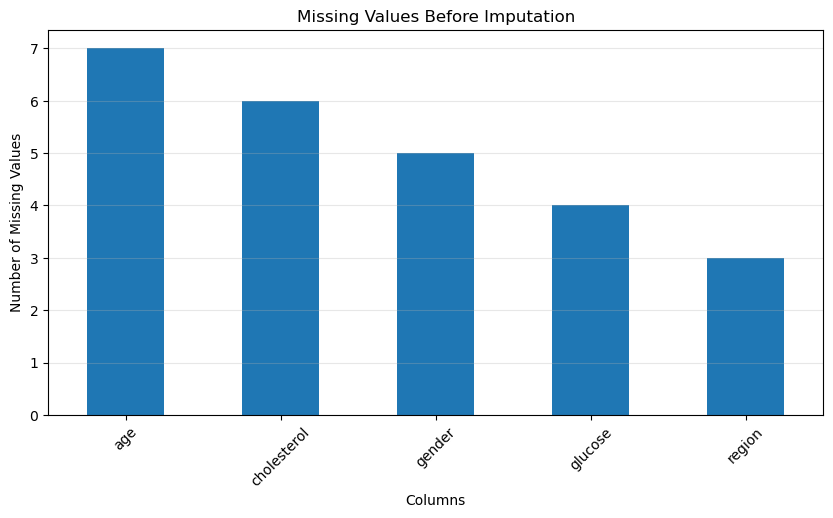

In [227]:
missing_before = (
    df_cleaned.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_before = missing_before[
    missing_before > 0
]

plt.figure(figsize=(10, 5))

missing_before.plot(kind="bar")

plt.title("Missing Values Before Imputation")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

### Missing Indicators

In [228]:
# Create missing indicator columns

columns_with_missing = [
    column
    for column in df_cleaned.columns
    if df_cleaned[column].isnull().any()
]

for column in columns_with_missing:
    
    df_cleaned[column + "_missing"] = (
        df_cleaned[column].isnull().astype(int)
    )

print("Missing indicator columns created:")
print(
    [
        column + "_missing"
        for column in columns_with_missing
    ]
)

Missing indicator columns created:
['age_missing', 'gender_missing', 'region_missing', 'cholesterol_missing', 'glucose_missing']


### Random Sample Imputation

In [229]:
# Random sample imputation

np.random.seed(42)

for column in columns_with_missing:
    
    # Patient ID ko random sample se fill nahi karenge
    if column == "patient_id":
        continue
    
    missing_count = df_cleaned[column].isnull().sum()
    
    if missing_count > 0:
        
        available_values = (
            df_cleaned[column]
            .dropna()
            .values
        )
        
        random_values = np.random.choice(
            available_values,
            size=missing_count,
            replace=True
        )
        
        df_cleaned.loc[
            df_cleaned[column].isnull(),
            column
        ] = random_values

print("Random sample imputation completed.")

Random sample imputation completed.


In [230]:
missing_after = df_cleaned.isnull().sum()

print("Missing Values After Imputation:")
print(missing_after)

Missing Values After Imputation:
patient_id             0
age                    0
gender                 0
region                 0
bmi                    0
blood_pressure         0
cholesterol            0
glucose                0
disease_risk           0
age_missing            0
gender_missing         0
region_missing         0
cholesterol_missing    0
glucose_missing        0
dtype: int64


### Before vs After Missing Values

In [231]:
missing_before_total = df_percentile_removed.isnull().sum().sum()
missing_after_total = df_cleaned.isnull().sum().sum()

missing_comparison = pd.DataFrame({
    "Before Imputation": [missing_before_total],
    "After Imputation": [missing_after_total]
})

missing_comparison

,Before Imputation,After Imputation
0,25,0


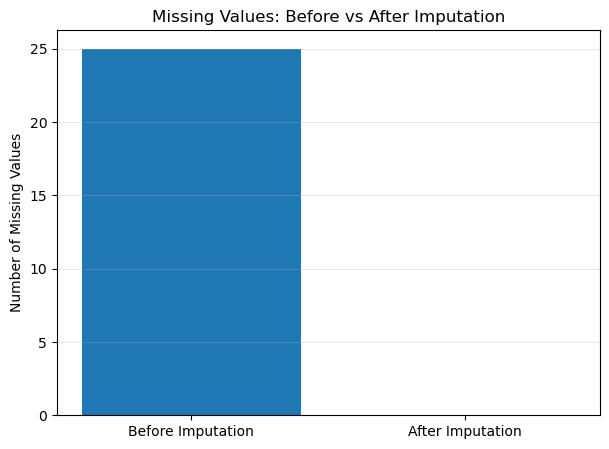

In [232]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Before Imputation", "After Imputation"],
    [
        missing_before_total,
        missing_after_total
    ]
)

plt.title("Missing Values: Before vs After Imputation")
plt.ylabel("Number of Missing Values")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Check Duplicate Records

In [233]:
duplicate_count = df_cleaned.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


### Final Dataset Information

In [234]:
print("========== FINAL CLEAN DATASET ==========")

print("Rows:", df_cleaned.shape[0])
print("Columns:", df_cleaned.shape[1])

print("\nMissing Values:",
      df_cleaned.isnull().sum().sum())

print("Duplicate Rows:",
      df_cleaned.duplicated().sum())

========== FINAL CLEAN DATASET ==========
Rows: 83
Columns: 14

Missing Values: 0
Duplicate Rows: 0


In [235]:
df_cleaned.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing,gender_missing,region_missing,cholesterol_missing,glucose_missing
0,1001,53.0,Male,East,25.4,88.0,246.2,71.4,1,0,0,0,0,0
1,1002,31.0,Female,North,27.2,125.9,218.9,108.2,0,0,0,0,0,0
2,1003,60.0,Female,North,33.1,117.5,194.1,147.5,1,0,0,0,0,0
4,1005,18.0,Male,North,25.4,136.2,193.3,70.0,0,0,0,0,0,0
5,1006,27.0,Male,East,27.3,127.2,150.0,91.4,1,0,0,0,1,0


In [236]:
print("========== DATA QUALITY CHECK ==========")

print("1. Missing Values:",
      df_cleaned.isnull().sum().sum())

print("2. Duplicate Rows:",
      df_cleaned.duplicated().sum())

print("3. Rows:",
      df_cleaned.shape[0])

print("4. Columns:",
      df_cleaned.shape[1])

========== DATA QUALITY CHECK ==========
1. Missing Values: 0
2. Duplicate Rows: 0
3. Rows: 83
4. Columns: 14


In [237]:
df_cleaned.to_csv(
    "patient_health_records_final_clean.csv",
    index=False
)

print(
    "patient_health_records_final_clean.csv "
    "created successfully!"
)

patient_health_records_final_clean.csv created successfully!


# HTML Report

In [238]:
# Find missing indicator columns

missing_indicator_columns = [
    col for col in df_cleaned.columns
    if col.endswith("_missing")
]

print("Missing Indicator Columns:")
print(missing_indicator_columns)

Missing Indicator Columns:
['age_missing', 'gender_missing', 'region_missing', 'cholesterol_missing', 'glucose_missing']


In [239]:
# Columns to exclude only from profiling

exclude_from_profile = missing_indicator_columns.copy()

if "patient_id" in df_cleaned.columns:
    exclude_from_profile.append("patient_id")

# Create a separate copy for profiling

profile_df = df_cleaned.drop(
    columns=exclude_from_profile,
    errors="ignore"
).copy()

print("Final Clean Dataset Shape:", df_cleaned.shape)
print("Profiling Dataset Shape:", profile_df.shape)

Final Clean Dataset Shape: (83, 14)
Profiling Dataset Shape: (83, 8)


In [242]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    profile_df,
    title="Patient Health Records Profiling Report",
    explorative=True
)



In [243]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 448.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [244]:
profile.to_file("patient_health_records_profiling_report_.html")

print("HTML report created successfully!")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

HTML report created successfully!


# Brief Report — Data Cleaning

## 1. Most Effective Imputation Strategy

MICE (Multiple Imputation by Chained Equations) was the most effective
imputation strategy for the numerical variables. It used information
from multiple variables to estimate the missing values.

For categorical variables such as Gender and Region, the most frequent
value method was used because these variables contain categories.

## 2. Best Outlier Handling Method

Winsorization preserved data quality best because it capped extreme
values instead of removing patient records. This helped keep the
dataset size unchanged while reducing the effect of extreme values.

The Z-score and IQR methods were useful for identifying and removing
extreme or unusual patient records as required.

## 3. Improvement After Data Cleaning

Data cleaning improved the usability of the Patient Health Records
dataset by:

- Treating missing values.
- Handling extreme and unusual values.
- Reducing the effect of outliers.
- Making the data more consistent.
- Making the dataset easier to analyze and visualize.
- Making the dataset more suitable for further analysis.

## Conclusion

Overall, MICE was effective for handling numerical missing values,
while Winsorization was useful for preserving data quality during
outlier treatment. After cleaning, the dataset became more consistent,
reliable, and suitable for further analysis.

# Final Result

The Patient Health Records dataset was successfully cleaned by treating
missing values and handling outliers.

The final dataset is now ready for further data analysis, visualization,
and machine learning.

# Expected Outcome

By the end of this project, I was able to:

1. Understand and apply different missing value imputation strategies.

2. Implement KNN and MICE for multivariate missing value imputation.

3. Detect and treat outliers using:
   - Z-score method
   - IQR method
   - Percentile method
   - Winsorization

4. Compare the dataset before and after missing value and outlier treatment.

5. Prepare a clean and machine-learning-ready dataset.

6. Create a profiling summary to understand the quality and structure of
   the Patient Health Records dataset.

## Final Outcome

The Patient Health Records dataset was cleaned by treating missing values
and handling outliers. The cleaned dataset is more consistent and suitable
for further data analysis, visualization, and machine learning.

In [247]:
# Check final cleaned dataset

print(df_cleaned.shape)
df_cleaned.head()

(83, 14)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing,gender_missing,region_missing,cholesterol_missing,glucose_missing
0,1001,53.0,Male,East,25.4,88.0,246.2,71.4,1,0,0,0,0,0
1,1002,31.0,Female,North,27.2,125.9,218.9,108.2,0,0,0,0,0,0
2,1003,60.0,Female,North,33.1,117.5,194.1,147.5,1,0,0,0,0,0
4,1005,18.0,Male,North,25.4,136.2,193.3,70.0,0,0,0,0,0,0
5,1006,27.0,Male,East,27.3,127.2,150.0,91.4,1,0,0,0,1,0


In [250]:
# Save final cleaned dataset

final_df.to_csv(
    "patient_health_records_final_clean.csv",
    index=False
)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [253]:
final_outlier_counts = {}

for column in final_outlier_columns:
    
    Q1 = final_df[column].quantile(0.25)
    Q3 = final_df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    count = (
        (final_df[column] < lower_limit) |
        (final_df[column] > upper_limit)
    ).sum()
    
    final_outlier_counts[column] = count

final_outlier_check = pd.DataFrame(
    list(final_outlier_counts.items()),
    columns=["Column", "Remaining Outliers"]
)

final_outlier_check

,Column,Remaining Outliers
0,bmi,0
1,blood_pressure,2
2,cholesterol,1
3,glucose,1
4,disease_risk,0


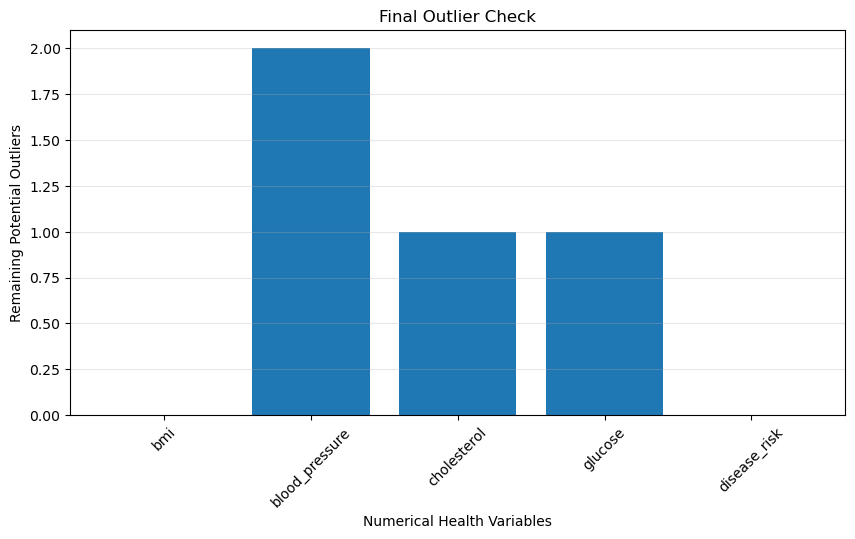

In [254]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_outlier_check["Column"],
    final_outlier_check["Remaining Outliers"]
)

plt.title("Final Outlier Check")
plt.xlabel("Numerical Health Variables")
plt.ylabel("Remaining Potential Outliers")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()